In [1]:
import os
import numpy as np
import mne
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

def procesar_eeg(filepath, patient_id, duration=2.0, overlap=0.5, devolver_series=False,# Preprocesamiento EEG pacientes
                 canales_interes=None):
    print(f"\nProcesando {patient_id} ({filepath}) ...")

    # 1) Leer archivo EEG (.set)
    raw = mne.io.read_raw_eeglab(filepath, preload=True)
    raw.filter(0.5, 45, fir_design='firwin')

    # Info útil
    print(
        f"Frecuencia de muestreo: {raw.info['sfreq']} Hz, "
        f"n_times: {raw.n_times}, "
        f"duración: {raw.n_times / raw.info['sfreq']:.2f} s"
    )

    # Montaje estándar (si aplica)
    try:
        montage = mne.channels.make_standard_montage('standard_1020')
        raw.set_montage(montage, on_missing='ignore')
    except Exception:
        pass

    # Filtrar canales de interés (opcional)
    if canales_interes is not None:
        picks = mne.pick_channels(raw.ch_names, include=canales_interes, ordered=False)
        if len(picks) == 0:
            raise ValueError(f"No se encontraron canales solicitados en {patient_id}")
        raw.pick(picks)

    # ICA (opcional)
    ica = mne.preprocessing.ICA(n_components=min(19, len(raw.ch_names)), random_state=42)
    ica.fit(raw)
    raw = ica.apply(raw)

    # 2) Epoching (¡sin reasignar drop_bad!)
    epochs = mne.make_fixed_length_epochs(raw, duration=duration, overlap=overlap, preload=True)
    epochs.load_data()        # asegurar datos en memoria para filtrados
    epochs.drop_bad()         # modifica en sitio; NO reasignar

    if len(epochs) == 0:
        raise ValueError(f"No se pudieron generar epochs para {patient_id}")

    # 3) Potencias por banda (como antes)
    # Theta
    epochs_theta = epochs.copy().filter(4, 8, fir_design='firwin')
    psd_theta = epochs_theta.compute_psd(method='welch', fmin=4, fmax=8, n_fft=256)
    psds_t, _ = psd_theta.get_data(return_freqs=True)          # (n_epochs, n_ch, n_freqs)
    theta_power_ch = psds_t.mean(axis=-1).mean(axis=0)         # promedio freqs y epochs -> por canal

    # Gamma slow
    epochs_gs = epochs.copy().filter(30, 60, fir_design='firwin')
    psd_gs = epochs_gs.compute_psd(method='welch', fmin=30, fmax=60, n_fft=256)
    psds_gs, _ = psd_gs.get_data(return_freqs=True)
    gamma_slow_power_ch = psds_gs.mean(axis=-1).mean(axis=0)

    # Gamma fast
    epochs_gf = epochs.copy().filter(60, 120, fir_design='firwin')
    psd_gf = epochs_gf.compute_psd(method='welch', fmin=60, fmax=120, n_fft=256)
    psds_gf, _ = psd_gf.get_data(return_freqs=True)
    gamma_fast_power_ch = psds_gf.mean(axis=-1).mean(axis=0)

    df_potencias = pd.DataFrame({
        "Paciente": patient_id,
        "Canal": epochs.ch_names,
        "Potencia_theta": theta_power_ch,
        "Potencia_gamma_slow": gamma_slow_power_ch,
        "Potencia_gamma_fast": gamma_fast_power_ch
    })

    if not devolver_series:
        return df_potencias

    # 4) Series temporales filtradas (para PAC)
    theta_data = epochs_theta.get_data()        # (n_epochs, n_ch, n_times)
    gs_data    = epochs_gs.get_data()
    gf_data    = epochs_gf.get_data()

    registros = []
    ch_names = epochs.ch_names
    for ep in range(len(epochs)):
        for ch_idx, canal in enumerate(ch_names):
            registros.append({
                "Paciente": patient_id,
                "Epoch": ep,
                "Canal": canal,
                "theta": theta_data[ep, ch_idx, :],       # np.array serie temporal
                "gamma_slow": gs_data[ep, ch_idx, :],
                "gamma_fast": gf_data[ep, ch_idx, :]
            })
    df_series = pd.DataFrame(registros)

    return df_potencias, df_series

def procesar_carpeta(input_dir, output_file="potencias_pacientes_controles.csv", devolver_series=True): # aplicar procesamiento a carpeta EEGs obtengo potencias medias y series temporales
    all_pot = []
    all_series = []

    for filename in os.listdir(input_dir):
        if filename.endswith(".set"):
            filepath = os.path.join(input_dir, filename)
            patient_id = os.path.splitext(filename)[0]
            try:
                if devolver_series:
                    df_pot, df_ser = procesar_eeg(filepath, patient_id, devolver_series=True)
                    all_pot.append(df_pot)
                    all_series.append(df_ser)
                else:
                    df_pot = procesar_eeg(filepath, patient_id, devolver_series=False)
                    all_pot.append(df_pot)
            except Exception as e:
                print(f"  ✖ Error en {filename}: {e}")

    if not all_pot:
        raise ValueError("No se procesó ningún archivo (.set no encontrado o todos fallaron).")

    df_pot_total = pd.concat(all_pot, ignore_index=True)
    df_pot_total.to_csv(output_file, index=False)
    print(f"\n✅ Potencias guardadas en: {output_file}")

    if devolver_series and all_series:
        df_series_total = pd.concat(all_series, ignore_index=True)
        # Ojo: guardar series (arrays) en CSV no es ideal. Mejor parquet o npz.
        # Aquí te lo devuelvo en memoria y tú decides cómo persistirlo.
        return df_pot_total, df_series_total

    return df_pot_total

In [3]:
input_dir = r"C:\Users\sebru\Downloads\eeg-controles (2)\eeg-controles" # <-- cambia aquí
output_file = "potencias_pacientes_controles.csv"

df_pot, df_series = procesar_carpeta(input_dir, output_file, devolver_series=True)

print("Potencias:")
print(df_pot.head())

print("\nSeries (arrays por fila):")
print(df_series.head())


Procesando sub-037_task-photomark_eeg (C:\Users\sebru\Downloads\eeg-controles (2)\eeg-controles\sub-037_task-photomark_eeg.set) ...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 3301 samples (6.602 s)

Frecuencia de muestreo: 500.0 Hz, n_times: 275100, duración: 550.20 s
Fitting ICA to data using 19 channels (please be patient, this may take a while)
Selecting by number: 19 components
Fitting ICA took 3.0s.
Applying ICA to Raw instance
    Transforming to ICA space (19 components)
    Zeroing out 0 I

In [4]:

df_series.to_csv("series_controles.csv", index=False)


In [5]:
import os
import numpy as np
import mne
import pandas as pd
import warnings
df_series = pd.read_csv("series_controles.csv")

In [6]:
from scipy.signal import hilbert

In [7]:
def modulation_index_tort(phase, amp_env, n_bins=18, eps=1e-12): 
    bins = np.linspace(-np.pi, np.pi, n_bins + 1) 
    amp_means = np.zeros(n_bins, float) 
    for i in range(n_bins): 
        idx = (phase >= bins[i]) & (phase < bins[i+1]) 
        amp_means[i] = amp_env[idx].mean() if np.any(idx) else 0.0 
    S = amp_means.sum() 
    if S <= eps: 
        return np.nan 
    P = amp_means / (S + eps) 
    H = -np.sum(P * np.log(P + eps)) 
    Hmax = np.log(n_bins) 
    return float((Hmax - H) / Hmax)

def pac_theta_gamma(df_series, n_bins=18, min_samples=200, n_surrogates=50, random_state=42):
    """
    Calcula MI (Tort) y PAC-z (z-score con surrogates por 'time shift')
    para θ–γ-slow y θ–γ-fast por (Paciente, Epoch, Canal) y resume por (Paciente, Canal).
    
    df_series: columnas ['Paciente','Epoch','Canal','theta','gamma_slow','gamma_fast'] (np.array o string por fila)
    """
    rng = np.random.default_rng(random_state)
    filas = []

    # Recorrer todos los pacientes en el DataFrame
    for paciente, df_sub in df_series.groupby("Paciente"):
        for row in df_sub.itertuples(index=False):
            epoch = row.Epoch
            canal = row.Canal

            theta = np.fromstring(str(row.theta).strip("[]"), sep=" ", dtype=float)
            gs    = np.fromstring(str(row.gamma_slow).strip("[]"), sep=" ", dtype=float)
            gf    = np.fromstring(str(row.gamma_fast).strip("[]"), sep=" ", dtype=float)

            n = min(theta.size, gs.size, gf.size)
            if n < min_samples:
                filas.append({
                    "Paciente": paciente, "Epoch": epoch, "Canal": canal,
                    "MI_gs": np.nan, "MI_gf": np.nan,
                    "PACz_gs": np.nan, "PACz_gf": np.nan
                })
                continue

            # Recortar al mismo tamaño
            theta, gs, gf = theta[:n], gs[:n], gf[:n]

            # Fase theta y envolventes gamma
            phase_theta = np.angle(hilbert(theta))
            env_gs = np.abs(hilbert(gs))
            env_gf = np.abs(hilbert(gf))

            # MI reales
            mi_gs = modulation_index_tort(phase_theta, env_gs, n_bins=n_bins)
            mi_gf = modulation_index_tort(phase_theta, env_gf, n_bins=n_bins)

            # Surrogates
            if n_surrogates > 0 and np.isfinite(mi_gs) and np.isfinite(mi_gf):
                low_shift = max(int(0.1*n), 1)
                hi_shift  = max(int(0.9*n), low_shift+1)

                sur_gs, sur_gf = [], []
                for _ in range(n_surrogates):
                    s = int(rng.integers(low=low_shift, high=hi_shift))
                    sur_gs.append(modulation_index_tort(phase_theta, np.roll(env_gs, s), n_bins=n_bins))
                    sur_gf.append(modulation_index_tort(phase_theta, np.roll(env_gf, s), n_bins=n_bins))

                mu_gs, sd_gs = np.nanmean(sur_gs), np.nanstd(sur_gs, ddof=1)
                mu_gf, sd_gf = np.nanmean(sur_gf), np.nanstd(sur_gf, ddof=1)
                pacz_gs = (mi_gs - mu_gs) / (sd_gs + 1e-12) if np.isfinite(sd_gs) and sd_gs > 0 else np.nan
                pacz_gf = (mi_gf - mu_gf) / (sd_gf + 1e-12) if np.isfinite(sd_gf) and sd_gf > 0 else np.nan
            else:
                pacz_gs, pacz_gf = np.nan, np.nan

            filas.append({
                "Paciente": paciente, "Epoch": epoch, "Canal": canal,
                "MI_gs": mi_gs, "MI_gf": mi_gf,
                "PACz_gs": pacz_gs, "PACz_gf": pacz_gf
            })

    df_epoch = pd.DataFrame(filas)

    # Promedio por Paciente+Canal (ignora NaNs)
    df_mean = (df_epoch
               .groupby(["Paciente","Canal"], as_index=False)[["MI_gs","MI_gf","PACz_gs","PACz_gf"]]
               .mean())

    return df_epoch, df_mean
            
        

In [ ]:

df_epoch, df_mean = pac_theta_gamma(df_series, n_bins=18, min_samples=200, n_surrogates=50)

print(df_mean.head(30))

In [ ]:
print(df_epoch.head())

                         Paciente  Epoch Canal     MI_gs     MI_gf   PACz_gs  \
0  sub-001_task-photomark_eeg (2)      0   Fp1  0.003311  0.000183  1.268684   
1  sub-001_task-photomark_eeg (2)      0   Fp2  0.001976  0.000098 -0.883121   
2  sub-001_task-photomark_eeg (2)      0    F3  0.002566  0.000081  0.923099   
3  sub-001_task-photomark_eeg (2)      0    F4  0.001738  0.000080 -0.256816   
4  sub-001_task-photomark_eeg (2)      0    C3  0.001756  0.000080  0.185642   

    PACz_gf  
0 -1.848282  
1 -1.686887  
2 -2.851763  
3 -1.887973  
4 -1.864897  


# PAC-Z por canal

**PACz_gs alto + PACz_gf bajo en zonas frontales/temporales →
suele ser característico en pacientes con Alzheimer o deterioro cognitivo leve.**

**Si comparas con un grupo control, esperarías el patrón inverso o más equilibrado.**

# Comparación MI_gs y MI_Gf

**Si ves que MI_gs > MI_gf de forma marcada en varios canales, eso puede reflejar el patrón característico en Alzheimer.**

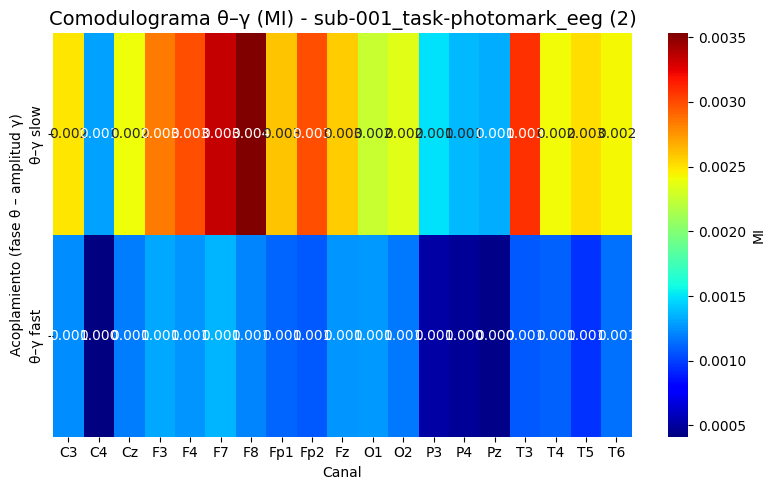

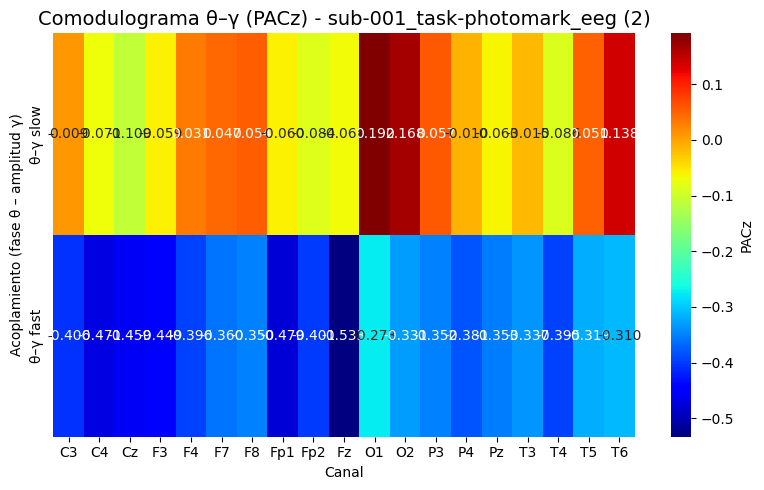

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Suponiendo que df_mean ya es tu DataFrame con columnas:
# ['Paciente','Canal','MI_gs','MI_gf','PACz_gs','PACz_gf']

def comodulograma_from_df(df, paciente, metric="MI"):
    """
    Representa comodulograma simplificado θ–γ (slow vs fast) 
    usando las métricas ya calculadas en df_mean.
    
    metric: "MI" o "PACz"
    """
    if metric == "MI":
        df_plot = df[["Canal","MI_gs","MI_gf"]].copy()
        df_plot.columns = ["Canal","θ–γ slow","θ–γ fast"]
    elif metric == "PACz":
        df_plot = df[["Canal","PACz_gs","PACz_gf"]].copy()
        df_plot.columns = ["Canal","θ–γ slow","θ–γ fast"]
    else:
        raise ValueError("metric debe ser 'MI' o 'PACz'")
    
    df_plot = df_plot.set_index("Canal")
    
    plt.figure(figsize=(8,5))
    sns.heatmap(df_plot.T, annot=True, fmt=".3f", cmap="jet", cbar_kws={"label": metric})
    plt.title(f"Comodulograma θ–γ ({metric}) - {paciente}", fontsize=14)
    plt.xlabel("Canal")
    plt.ylabel("Acoplamiento (fase θ – amplitud γ)")
    plt.tight_layout()
    plt.show()

# Ejemplo de uso:
comodulograma_from_df(df_mean, paciente="sub-001_task-photomark_eeg (2)", metric="MI")
comodulograma_from_df(df_mean, paciente="sub-001_task-photomark_eeg (2)", metric="PACz")

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def comodulograma_from_df(df, paciente, metric="MI", save_dir="C:/Users/sebru/Downloads/comodulogramas_controles"):
    if metric == "MI":
        df_plot = df[["Canal","MI_gs","MI_gf"]].copy()
        df_plot.columns = ["Canal","θ–γ slow","θ–γ fast"]
    elif metric == "PACz":
        df_plot = df[["Canal","PACz_gs","PACz_gf"]].copy()
        df_plot.columns = ["Canal","θ–γ slow","θ–γ fast"]
    else:
        raise ValueError("metric debe ser 'MI' o 'PACz'")
    
    df_plot = df_plot.set_index("Canal")
    
    plt.figure(figsize=(10,5))
    sns.heatmap(
        df_plot.T,
        annot=True,
        fmt=".2g",                # notación más compacta
        annot_kws={"size": 8},    # letras más pequeñas
        cmap="viridis",           # colores suaves y legibles
        cbar_kws={"label": metric}
    )
    plt.title(f"Comodulograma θ–γ ({metric}) - {paciente}", fontsize=14, pad=15)
    plt.xlabel("Canal", fontsize=12)
    plt.ylabel("Acoplamiento (fase θ – amplitud γ)", fontsize=12)
    plt.xticks(rotation=45, ha="right")  # evita solapamientos en etiquetas de canales
    plt.tight_layout()
    
    os.makedirs(save_dir, exist_ok=True)
    fname = f"{paciente}_{metric}.png".replace(" ", "_")
    plt.savefig(os.path.join(save_dir, fname), dpi=300)
    plt.close()

# Loop por cada paciente
for paciente, df_pac in df_mean.groupby("Paciente"):
    comodulograma_from_df(df_pac, paciente, metric="MI")
    comodulograma_from_df(df_pac, paciente, metric="PACz")

print(f"HE TERMINAOOOOO")



HE TERMINAOOOOO


In [ ]:
for chunk in pd.read_csv("series.csv", chunksize=100000):
    print(chunk.head(2))   # muestra 2 filas por cada bloque

                         Paciente  Epoch Canal  \
0  sub-001_task-photomark_eeg (2)      0   Fp1   
1  sub-001_task-photomark_eeg (2)      0   Fp2   

                                               theta  \
0  [ 6.77605981e-06  6.82334698e-06  6.84119285e-...   
1  [ 7.07864308e-06  7.09241634e-06  7.08250741e-...   

                                          gamma_slow  \
0  [ 8.42276694e-07  1.51839116e-06  2.07533987e-...   
1  [-3.90701493e-08  7.38296383e-07  1.51941613e-...   

                                          gamma_fast  
0  [-1.61775202e-07 -3.00408881e-07 -3.15643952e-...  
1  [-2.31367952e-07 -3.18288006e-07 -2.61646105e-...  
                          Paciente  Epoch Canal  \
100000  sub-021_task-photomark_eeg    157    F4   
100001  sub-021_task-photomark_eeg    157    C3   

                                                    theta  \
100000  [-7.00849946e-05 -5.91796310e-05 -4.77138724e-...   
100001  [-7.04092345e-05 -5.94117630e-05 -4.78482083e-...   

        

In [ ]:
import os 
directory = os.getcwd()
print(f"DIRECTORIO: {directory}")

DIRECTORIO: c:\Users\sebru\Downloads
